# Imports


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_repo_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "analog_qec").is_dir() and (candidate / "notebook").is_dir():
            return candidate
    raise RuntimeError("Could not find the analog-qec repository root")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analog_qec.exponent_comparison import (
    apply_plot_style,
    build_comparison_points,
    default_exponent_comparison_config,
    default_plot_config,
    plot_exponent_comparison,
)

plot_config = default_plot_config()
apply_plot_style(plot_config)

FIGURE_DIR = REPO_ROOT / "notebook" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


# Configuration


In [ ]:
comparison_config = default_exponent_comparison_config()
comparison_points = build_comparison_points(comparison_config)
len(comparison_points)


## Exponent-based comparison

This plot uses a cumulative register error exponent $H$ on the x-axis and keeps the register failure probability $P_\mathrm{fail}=1-e^{-H}$ as the top-axis interpretation. The benchmark is specified by dimensionless angular analog evolution time $Jt$. Here a 25 ns interaction time means one full $2\pi$ rotation, so the physical time per unit $Jt$ is $25\,\mathrm{ns}/2\pi$. Raw and EPS use this physical analog time, while surface code and STAR use an optimistic edge-colored Trotterization of the same $Jt$.

All analog and logical-lifetime exponents use an effective transverse coherence time $T_2$ in $H=nT_\mathrm{err}/T_2$. In the raw analog case this $T_2$ is dominated by pure dephasing, so we label the swept parameter as $T_\phi$. In the EPS case pure dephasing is assumed to be removed, so the limiting value is $T_2=2T_1$ and the plotted EPS labels quote the corresponding $T_1$.

For the surface-code baseline, the time factor is circuit depth, not total T count: T gates on different edges/registers are parallelized into edge-color and synthesis-depth layers. The total T count is used only to size an optimistic magic-state factory area, with no routing overhead or factory-induced stalls. STAR is plotted as a partial-FTQC literature baseline: it keeps the same Trotterized Pauli-rotation structure as the surface-code branch, but directly implements arbitrary rotations through injected analog-rotation states instead of Clifford+T synthesis and magic-state distillation. Its plotted exponent is $H_\mathrm{STAR}=H_\mathrm{rot}+H_\mathrm{Cliff}$, with $H_\mathrm{rot}=N_\mathrm{rot}/N_\mathrm{rot,budget}$ and $N_\mathrm{rot,budget}=1/[2(2p/15)]$ matching the STAR paper's two-RUS-step average. The Clifford term uses the paper's fitted logical-round scaling for $d=3,5,7,9$ as a sensitivity estimate, and we show STAR traces for $p=5\times10^{-5}$, $p=10^{-4}$, and $p=5\times10^{-4}$. All STAR points use the same 50-site benchmark; the d=9 point therefore extrapolates beyond the paper's $10^4$-physical-qubit anchor.


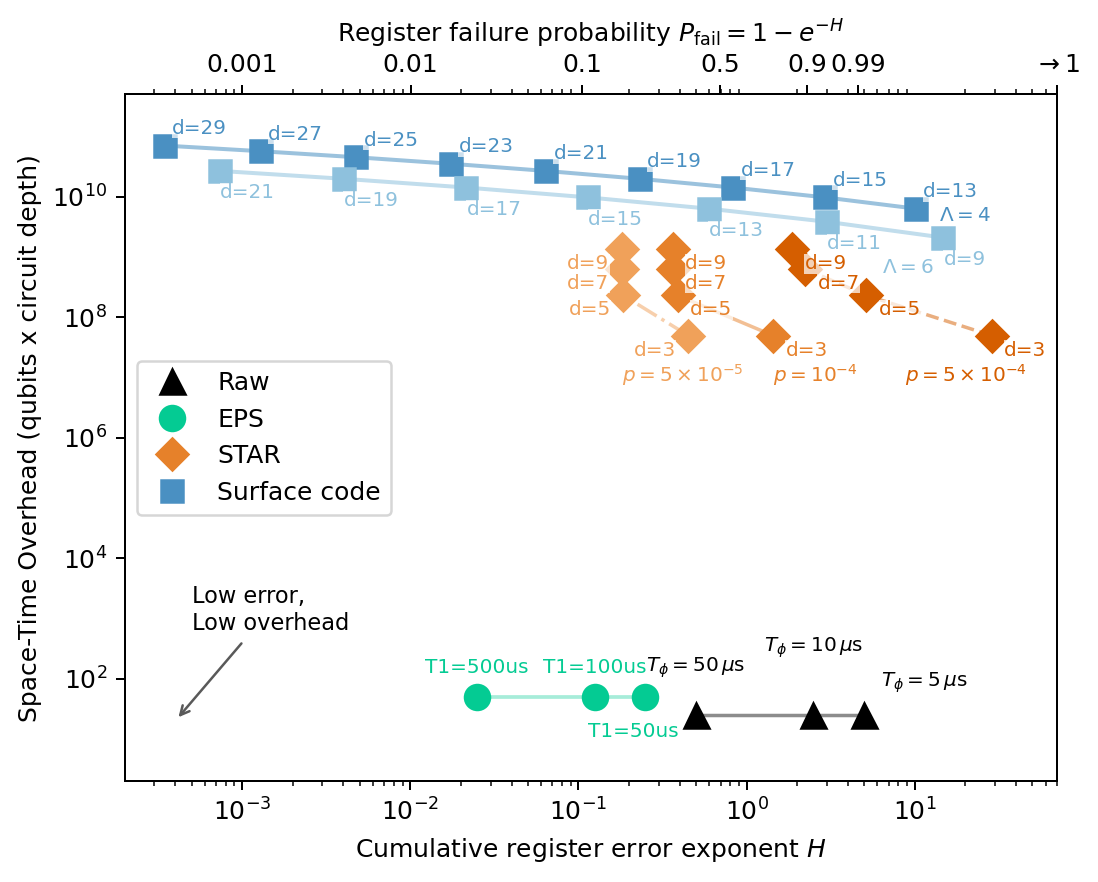

[{'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=5\\,\\mu\\mathrm{s}$',
  'H': 5.0,
  'P_fail': 0.9932620530009145,
  'nT': 25.0},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=10\\,\\mu\\mathrm{s}$',
  'H': 2.5,
  'P_fail': 0.9179150013761012,
  'nT': 25.0},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=50\\,\\mu\\mathrm{s}$',
  'H': 0.5,
  'P_fail': 0.3934693402873666,
  'nT': 25.0},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=50us',
  'H': 0.25,
  'P_fail': 0.22119921692859512,
  'nT': 50.0},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=100us',
  'H': 0.125,
  'P_fail': 0.11750309741540454,
  'nT': 50.0},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=500us',
  'H': 0.025,
  'P_fail': 0.024690087971667385,
  'nT': 50.0},
 {'scheme': 'STAR',
  'group': 'STAR p=5e-05',
  'label': 'd=3',
  'H': 0.4495605720037539,
  'P_fail': 0.36209159514616096,
  'nT': 49766400.0,
  'd': 3,
  'p_phys': 5e-05,
  'n_logical': 

In [9]:
fig, ax = plot_exponent_comparison(comparison_points, plot_config=plot_config)
output_path = FIGURE_DIR / "joint_space_time_error_exponent.pdf"
fig.savefig(output_path, format="pdf", bbox_inches="tight")
plt.show()

[point.as_dict() for point in comparison_points]
